In [2]:
# Import Packages
import os
import re
import sys
import time
import copy
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, GroupKFold

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV

from sklearn.feature_selection import VarianceThreshold

#%load_ext autoreload
#%reload_ext autoreload
#%autoreload 2
#from model_functions import *

%run Model_functions.ipynb

In [3]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

!chmod 644 ~/.local/share/jupyter/history.sqlite
#!rm ~/.local/share/jupyter/history.sqlite

chmod: /Users/kosaraju_b/.local/share/jupyter/history.sqlite: No such file or directory


In [9]:
NISAR_DATA_CSV = "../../DATA/AGB_DATA/Merged_Data/NISAR/nisar_data.csv"

# SENTINEL DATA

In [14]:
data_df = pd.read_csv(NISAR_DATA_CSV)
print(data_df.shape)
data_df.columns

(123, 5)


Index(['date', 'longitude', 'latitude', 'nisar_value_hvhv',
       'nisar_value_hhhh'],
      dtype='object')

## DATA PREPROCESSING

In [15]:
#sentinel_df = handle_null_data(sentinel_df)
data_df = data_df.dropna()
data_df.shape

(123, 5)

In [41]:
non_feature_cols = [
    'plant_AGB_kg',        # Target variable
    'dataset',             # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    #'latitude',            # coordinate
    #'longitude',           # coordinate
]

sentinel_bands = [
    'Blue', 'Green', 'Red', 'NIR',
    'SWIR1', 'SWIR2', 'NDVI', 'MNDWI',
    'NBR', 'EVI', 'CLOUD_COVERAGE'
]
X_bands = sentinel_df[sentinel_bands]

target = 'plant_AGB_kg'
feature_cols = [c for c in sentinel_df.columns if c not in non_feature_cols]

X = sentinel_df[feature_cols]
y = sentinel_df[target]



print(f"Features : {len(feature_cols)}")
print(f"Num rows : {len(sentinel_df)}")

Features : 18
Num rows : 8160


In [42]:
groups = sentinel_df['dataset']
groups.unique()

array(['ElSalvador', 'CostaRica-Nicoya', 'Belige', 'Honduras-Blanca',
       'Brazil-2', 'Brazil-3', 'Brazil-4', 'Brazil-6', 'Brazil-8',
       'Brazil-11'], dtype=object)

### Find correlations

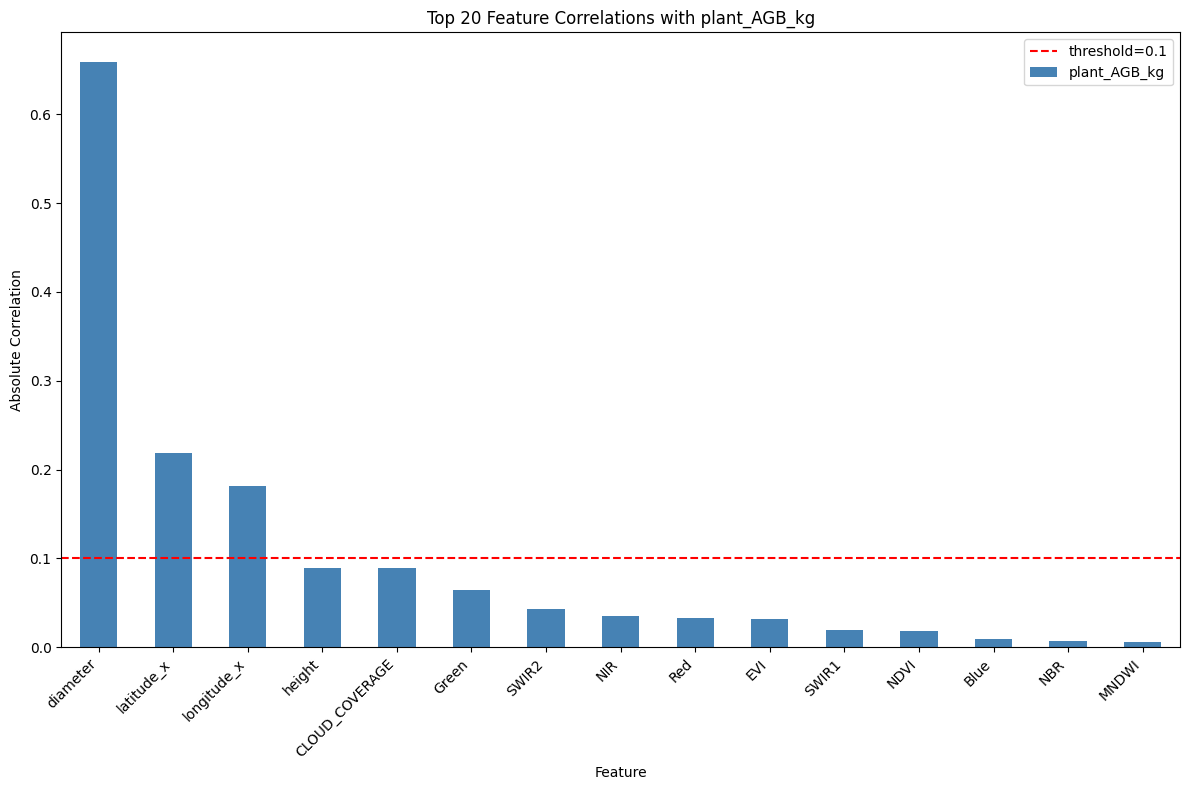

diameter          0.659274
latitude_x        0.218484
longitude_x       0.181346
height            0.089419
CLOUD_COVERAGE    0.089051
Green             0.063990
SWIR2             0.043671
NIR               0.034798
Red               0.033172
EVI               0.032414
SWIR1             0.019143
NDVI              0.018816
Blue              0.009083
NBR               0.007454
MNDWI             0.005801
Name: plant_AGB_kg, dtype: float64


In [43]:
numerical_cols = get_numerical_cols(X)
target_corr = plot_correlation_matrix(X[numerical_cols], y, top_n=20)
print(target_corr)

Columns with a Pearson correlation coefficient (r) between -0.1 and 0.1 with the target variable are generally considered to have a negligible or very weak relationship.

### Remove Low Variance Features (cols)

### Remove Features With Weak Correlation to Target

### Convert categorical variables to one-hot encoding

# LINEAR REGRESSION

In [44]:
%run Model_functions.ipynb

In [45]:
label_1 = "Sentinel bands only"
results = linear_reg_groups(X_s, y, groups, label_1)


--- Sentinel bands only ---
Test R²     : -1.3052
Test RMSE   : 803.91 kg
Train R²    : 0.0379
Train RMSE  : 150.85 kg
Num Features: 11

 Cross-validation ---
CV R² mean: -113.8519
CV R² std : 217.2382
CV scores : [-1.09500e+00 -3.75120e+01 -4.98296e+02 -6.94100e+00 -5.93119e+02
 -1.40900e+00 -8.10000e-02 -7.40000e-02  2.40000e-02 -1.80000e-02]

Grouped Cross-validation ---
Grouped CV R² mean: -361.1340
Grouped CV R² std : 994.4947
Grouped CV scores : [-2.000000e-03 -7.944000e+00 -7.400000e-02 -1.316800e+01 -5.300000e-02
 -3.336363e+03 -2.506350e+02 -1.299000e+00 -9.430000e-01 -8.590000e-01]


# RANDOM FOREST

In [47]:
label_1 = "Sentinel bands only"
results = randomForest_groups(X_s,
                              y,
                              groups,
                              label_1)
show_importances(results)

EXPERIMENT  : Sentinel bands only
Test R²     : -0.0114
Test RMSE   : 532.50 kg
Train R²    : 0.4333
Train RMSE  : 115.77 kg
Num Features: 11

 Cross-validation ---
CV R² mean: -283.6807
CV R² std : 708.1158
CV scores : [-1.921000e+00 -1.153620e+02 -2.063040e+02 -1.138130e+02 -2.397957e+03
 -9.260000e-01 -1.110000e-01 -1.030000e-01 -7.300000e-02 -2.350000e-01]

Grouped Cross-validation ---
Grouped CV R² mean: -361.1340
Grouped CV R² std : 994.4947
Grouped CV scores : [-2.000000e-03 -7.944000e+00 -7.400000e-02 -1.316800e+01 -5.300000e-02
 -3.336363e+03 -2.506350e+02 -1.299000e+00 -9.430000e-01 -8.590000e-01]

Top 4 feature importances:
  MNDWI                                         0.1311  ██████
  CLOUD_COVERAGE                                0.1183  █████
  NBR                                           0.0950  ████
  Green                                         0.0923  ████
